In [23]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

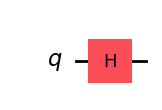

In [24]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [25]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [26]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [27]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [28]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

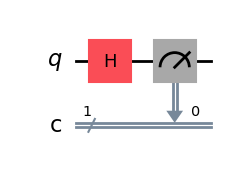

In [29]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [30]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [31]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 510, '1': 514}


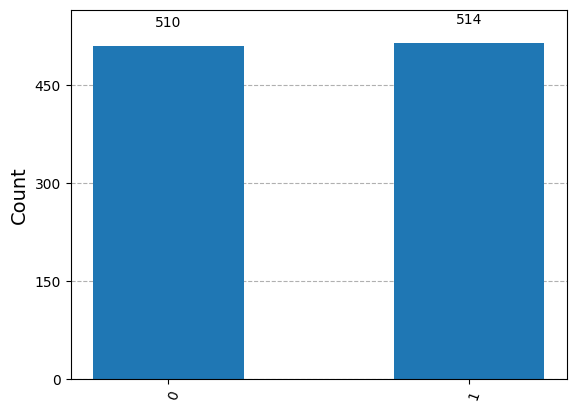

In [32]:
# We can also produce a graph

plot_histogram(counts)

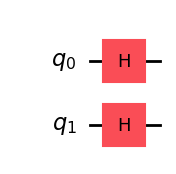

In [33]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [34]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

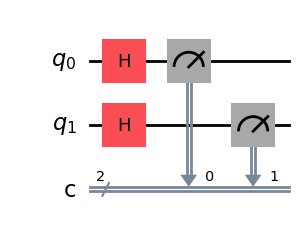

In [35]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

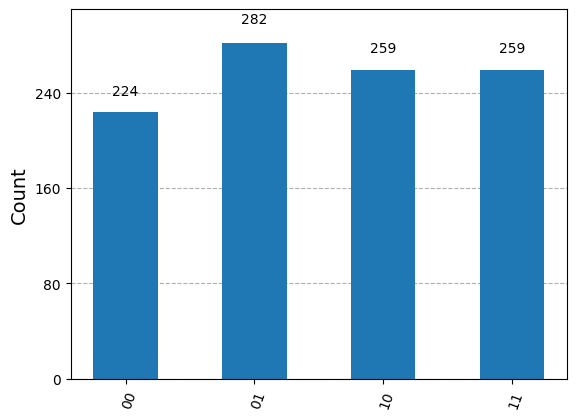

In [36]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

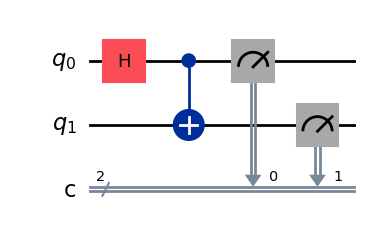

In [37]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

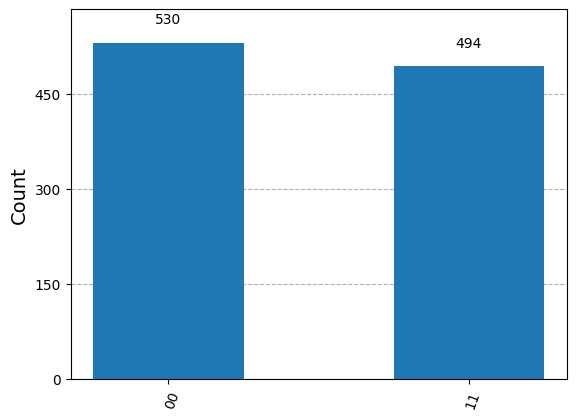

In [38]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

Phi plus: (|00> + |11>) / sqrt(2)


<IPython.core.display.Latex object>

{'11': 516, '00': 508}


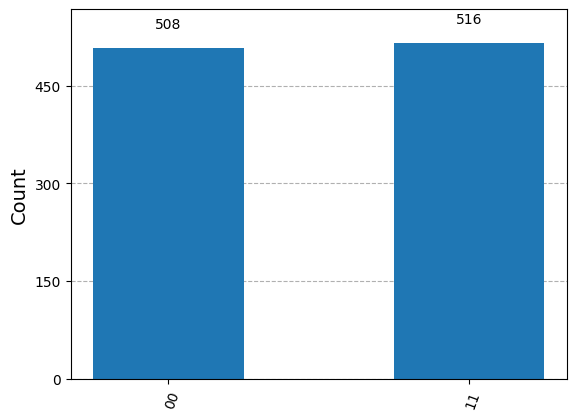

--------------------------------------------------
Phi minus: (|00> - |11>) / sqrt(2)


<IPython.core.display.Latex object>

{'11': 517, '00': 507}


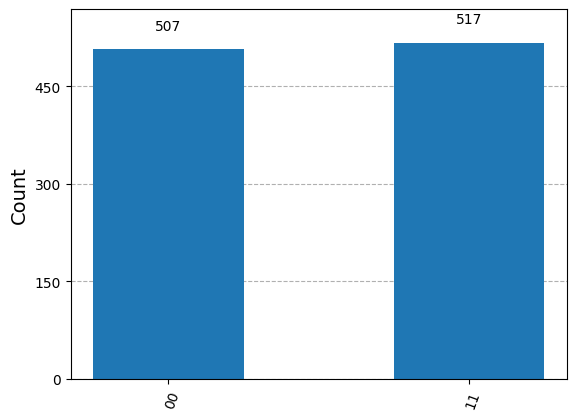

--------------------------------------------------
Psi plus: (|01> + |10>) / sqrt(2)


<IPython.core.display.Latex object>

{'01': 521, '10': 503}


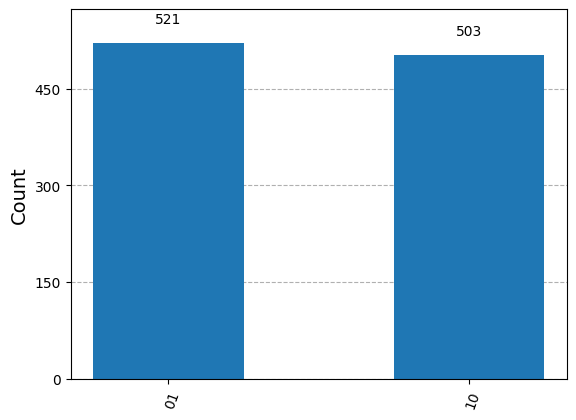

--------------------------------------------------
Psi minus: (|01> - |10>) / sqrt(2)


<IPython.core.display.Latex object>

{'01': 540, '10': 484}


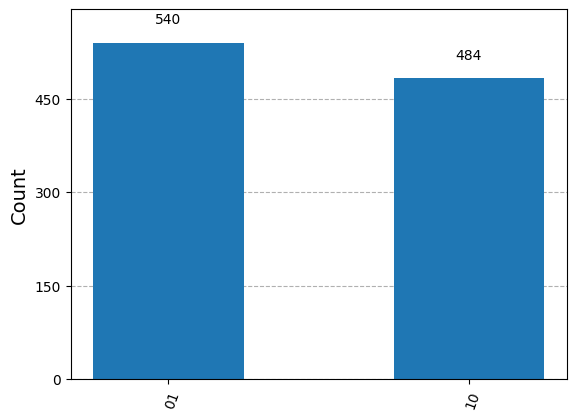

--------------------------------------------------


In [41]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

backend = BasicSimulator()

# display statevector and measurement counts
def test_bell_state(name, circuit_without_measurement):
    print(name)

    # check statevector before measurement
    state = Statevector.from_int(0, 4)
    state = state.evolve(circuit_without_measurement)
    display(state.draw("latex"))

    # add measurement
    measured_circuit = QuantumCircuit(2, 2)
    measured_circuit.compose(circuit_without_measurement, inplace=True)
    measured_circuit.measure(range(2), range(2))

    # simulate measurement
    qc_compiled = transpile(measured_circuit, backend)
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)
    print(counts)
    display(plot_histogram(counts))
    print("-" * 50)


# 1/sqrt(2) ( |00> + |11> )
bell_phi_plus = QuantumCircuit(2)
bell_phi_plus.h(0)
bell_phi_plus.cx(0, 1)

test_bell_state("Phi plus: (|00> + |11>) / sqrt(2)", bell_phi_plus)


# 1/sqrt(2) ( |00> - |11> )
# Add Z to qubit 0 after creating phi plus.
bell_phi_minus = QuantumCircuit(2)
bell_phi_minus.h(0)
bell_phi_minus.cx(0, 1)
bell_phi_minus.z(0)

test_bell_state("Phi minus: (|00> - |11>) / sqrt(2)", bell_phi_minus)


# 1/sqrt(2) ( |01> + |10> )
# add X to qubit 1 after creating phi plus.
bell_psi_plus = QuantumCircuit(2)
bell_psi_plus.h(0)
bell_psi_plus.cx(0, 1)
bell_psi_plus.x(1)

test_bell_state("Psi plus: (|01> + |10>) / sqrt(2)", bell_psi_plus)


# 1/sqrt(2) ( |01> - |10> )
# add X and Z after creating phi plus.
bell_psi_minus = QuantumCircuit(2)
bell_psi_minus.h(0)
bell_psi_minus.cx(0, 1)
bell_psi_minus.x(1)
bell_psi_minus.z(0)

test_bell_state("Psi minus: (|01> - |10>) / sqrt(2)", bell_psi_minus)

GHZ state with 3 qubits


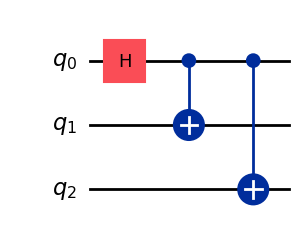

<IPython.core.display.Latex object>

{'000': 503, '111': 521}


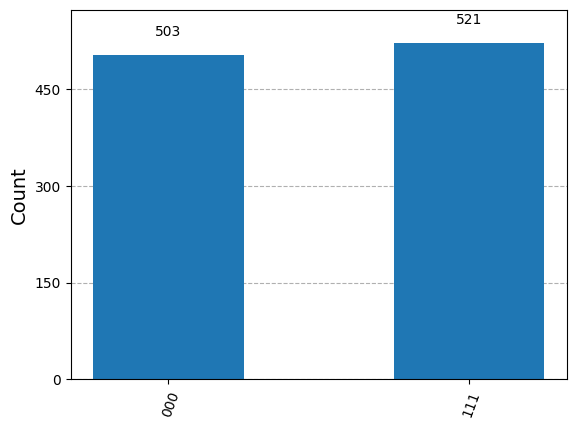

In [43]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

# EXERCISE 2: GHZ state for any number of qubits

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

backend = BasicSimulator()

def make_ghz_circuit(num_qubits):
    """
    Creates a GHZ state:
    1/sqrt(2) ( |00...0> + |11...1> )
    """
    circuit = QuantumCircuit(num_qubits)

    # Put the first qubit into superposition
    circuit.h(0)

    # Entangle every other qubit with qubit 0
    for target in range(1, num_qubits):
        circuit.cx(0, target)

    return circuit


def test_ghz_state(num_qubits, shots=1024, show_statevector=True):
    print(f"GHZ state with {num_qubits} qubits")

    circuit = make_ghz_circuit(num_qubits)
    display(circuit.draw("mpl"))

    # Statevector grows as 2^num_qubits, so only display for smaller examples
    if show_statevector:
        state = Statevector.from_int(0, 2 ** num_qubits)
        state = state.evolve(circuit)
        display(state.draw("latex"))

    # Add measurements
    measured_circuit = QuantumCircuit(num_qubits, num_qubits)
    measured_circuit.compose(circuit, inplace=True)
    measured_circuit.measure(range(num_qubits), range(num_qubits))

    # Simulate
    qc_compiled = transpile(measured_circuit, backend)
    job_sim = backend.run(qc_compiled, shots=shots)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)

    print(counts)
    display(plot_histogram(counts))


# Try with 3 qubits
test_ghz_state(3)

The simulator can handle up to about 25 qubits in a reasonable time on my machine. After that, the runtime and memory usage increase significantly. This is because simulating n qubits requires storing 2^n amplitudes, so the cost grows exponentially.